# EpiSat - Applied Computer Vision
## Classificacao de areas ambientais de risco epidemiologico em imagens Sentinel-2

Este notebook implementa a parte de **Applied Computer Vision** do projeto EpiSat para a Global Solution 2026.

A proposta tecnica e treinar redes neurais convolucionais do zero para classificar imagens satelitais RGB derivadas do Sentinel-2, usando o dataset EuroSAT, em quatro categorias ambientais relacionadas a vigilancia epidemiologica.

## Objetivo da disciplina ACV

Construir uma solucao de visao computacional com:

1. Dataset documentado, com classes, quantidade de imagens, divisao treino, validacao e teste.
2. Duas CNNs proprias, treinadas do zero, sem modelos pre-treinados.
3. Avaliacao por acuracia, loss, matriz de confusao, F1-score e exemplos de acertos e erros.
4. Comparacao tecnica entre as arquiteturas.
5. Demo funcional para predicao de uma nova imagem.

## Observacao metodologica

A classe `corpos_agua` representa corpos hidricos visiveis na imagem. O modelo nao diferencia diretamente agua corrente de agua estagnada. Portanto, a interpretacao epidemiologica deve ser feita como sinal visual ambiental potencialmente relevante, nao como diagnostico direto de foco vetorial.


## 0. Instalacao e configuracao inicial

Execute esta celula no Google Colab. Recomenda-se ativar GPU em:

`Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU`


In [1]:
# Instalacao de dependencias adicionais para o Colab
!pip install -q gradio scikit-learn matplotlib pandas pillow


In [2]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Dispositivo: cpu


## 1. Definicao do problema e das classes

O dataset utilizado e o EuroSAT RGB, construido a partir de imagens Sentinel-2. Cada imagem possui 64 x 64 pixels e 3 canais RGB.

As classes originais do EuroSAT foram remapeadas para quatro categorias operacionais do EpiSat:

| Classe EpiSat | Classes EuroSAT utilizadas | Interpretacao ambiental |
|---|---|---|
| `corpos_agua` | `River`, `SeaLake` | rios, lagos e corpos hidricos visiveis |
| `vegetacao_densa` | `Forest`, `HerbaceousVegetation` | vegetacao, cobertura verde e areas umidas potenciais |
| `area_urbana` | `Residential`, `Industrial` | malha urbana e areas construidas |
| `area_agricola` | `AnnualCrop`, `Pasture`, `PermanentCrop` | areas agricolas e pastoris |

Esta classificacao visual pode alimentar o EpiSat como uma camada ambiental complementar ao modelo epidemiologico principal.


In [3]:
# Parametros principais
DATA_ROOT = Path('/content/data')
ARTIFACTS_DIR = Path('/content/episat_artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 2
# Aumentado para 1000: mais dados = melhor estimativa de distribuicao por classe
IMAGES_PER_CLASS = 1000    # 1000 x 4 = 4000 imagens
EPOCHS_MODEL_1 = 30
EPOCHS_MODEL_2 = 45
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 10

class_names = ['corpos_agua', 'vegetacao_densa', 'area_urbana', 'area_agricola']
num_classes = len(class_names)

EUROSAT_TO_EPISAT = {
    'River': 'corpos_agua',
    'SeaLake': 'corpos_agua',
    'Forest': 'vegetacao_densa',
    'HerbaceousVegetation': 'vegetacao_densa',
    'Residential': 'area_urbana',
    'Industrial': 'area_urbana',
    'AnnualCrop': 'area_agricola',
    'Pasture': 'area_agricola',
    'PermanentCrop': 'area_agricola'
}

episat_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_episat = {i: name for name, i in episat_to_idx.items()}
print(episat_to_idx)


{'corpos_agua': 0, 'vegetacao_densa': 1, 'area_urbana': 2, 'area_agricola': 3}


## 2. Download do EuroSAT RGB e construcao do dataset EpiSat

O download e feito diretamente pelo `torchvision.datasets.EuroSAT`.

O dataset final e balanceado artificialmente por amostragem, mantendo o mesmo numero de imagens por classe EpiSat.


In [4]:
# Transformacao basica apenas para leitura inicial
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

full_eurosat = datasets.EuroSAT(
    root=str(DATA_ROOT),
    download=True,
    transform=base_transform
)

original_classes = full_eurosat.classes
print('Classes originais EuroSAT:')
print(original_classes)
print('Total de imagens EuroSAT:', len(full_eurosat))


100%|██████████| 94.3M/94.3M [00:00<00:00, 276MB/s]


Classes originais EuroSAT:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total de imagens EuroSAT: 27000


In [5]:
# Criacao de indices balanceados para as quatro classes EpiSat
indices_by_episat_class = defaultdict(list)

for idx, (_, original_label_idx) in enumerate(full_eurosat.samples):
    original_class = original_classes[original_label_idx]
    if original_class in EUROSAT_TO_EPISAT:
        episat_class = EUROSAT_TO_EPISAT[original_class]
        indices_by_episat_class[episat_class].append(idx)

for cls in class_names:
    print(cls, 'imagens disponiveis:', len(indices_by_episat_class[cls]))

selected_indices = []
selected_labels = []

for cls in class_names:
    available = indices_by_episat_class[cls]
    if len(available) < IMAGES_PER_CLASS:
        raise ValueError(f'Classe {cls} possui apenas {len(available)} imagens, abaixo de IMAGES_PER_CLASS={IMAGES_PER_CLASS}')
    chosen = random.sample(available, IMAGES_PER_CLASS)
    selected_indices.extend(chosen)
    selected_labels.extend([episat_to_idx[cls]] * len(chosen))

print('Total selecionado:', len(selected_indices))
print('Distribuicao:', Counter(selected_labels))


corpos_agua imagens disponiveis: 5500
vegetacao_densa imagens disponiveis: 6000
area_urbana imagens disponiveis: 5500
area_agricola imagens disponiveis: 7500
Total selecionado: 4000
Distribuicao: Counter({0: 1000, 1: 1000, 2: 1000, 3: 1000})


In [6]:
class EpiSatEuroSAT(torch.utils.data.Dataset):
    def __init__(self, eurosat_dataset, index_to_episat_label, transform=None):
        self.eurosat_dataset = eurosat_dataset
        self.index_to_episat_label = index_to_episat_label
        self.transform = transform
        self.loader = eurosat_dataset.loader
        self.samples = eurosat_dataset.samples
        # Pre-computar para evitar list(dict.keys()) O(n) em cada __getitem__
        self._keys = list(index_to_episat_label.keys())

    def __len__(self):
        return len(self._keys)

    def __getitem__(self, position):
        original_index = self._keys[position]  # O(1)
        path, _ = self.samples[original_index]
        image = self.loader(path).convert('RGB')
        label = self.index_to_episat_label[original_index]
        if self.transform:
            image = self.transform(image)
        return image, label

index_to_label = {idx: label for idx, label in zip(selected_indices, selected_labels)}
selected_original_indices = list(index_to_label.keys())
selected_y = list(index_to_label.values())

print('Amostras no dataset EpiSat:', len(index_to_label))


Amostras no dataset EpiSat: 4000


## 3. Pre-processamento e divisao treino, validacao e teste

A divisao segue 70% treino, 15% validacao e 15% teste, com estratificacao por classe.

O conjunto de treino recebe data augmentation mais agressiva (rotacao ate 90 graus, RandomResizedCrop) adequada para imagens satelitais, que nao possuem orientacao preferencial. Validacao e teste usam apenas normalizacao.


In [7]:
train_indices, temp_indices, y_train, y_temp = train_test_split(
    selected_original_indices,
    selected_y,
    test_size=0.30,
    random_state=SEED,
    stratify=selected_y
)

val_indices, test_indices, y_val, y_test = train_test_split(
    temp_indices,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print('Treino:', len(train_indices), Counter(y_train))
print('Validacao:', len(val_indices), Counter(y_val))
print('Teste:', len(test_indices), Counter(y_test))


Treino: 2800 Counter({0: 700, 1: 700, 2: 700, 3: 700})
Validacao: 600 Counter({1: 150, 2: 150, 0: 150, 3: 150})
Teste: 600 Counter({1: 150, 2: 150, 3: 150, 0: 150})


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    # scale=(0.9, 1.0): recorte leve — preserva features em imagens 64x64
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.0)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = EpiSatEuroSAT(full_eurosat, {idx: index_to_label[idx] for idx in train_indices}, transform=train_transform)
val_dataset   = EpiSatEuroSAT(full_eurosat, {idx: index_to_label[idx] for idx in val_indices},   transform=val_test_transform)
test_dataset  = EpiSatEuroSAT(full_eurosat, {idx: index_to_label[idx] for idx in test_indices},  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders criados.')
print(f'Treino: {len(train_dataset)} | Val: {len(val_dataset)} | Teste: {len(test_dataset)}')


DataLoaders criados.
Treino: 2800 | Val: 600 | Teste: 600


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


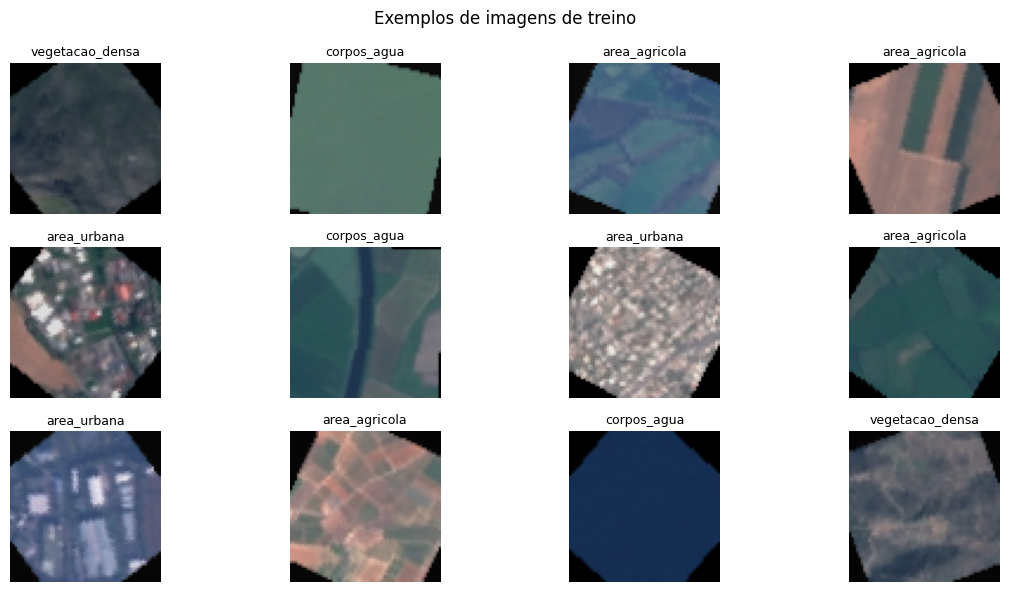

In [9]:
def denormalize_tensor(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0, 1)

def show_batch(loader, title='Amostras do dataset'):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        img = denormalize_tensor(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(idx_to_episat[int(labels[i])], fontsize=9)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_batch(train_loader, 'Exemplos de imagens de treino')


## 4. Arquiteturas CNN treinadas do zero

Foram implementadas duas arquiteturas proprias:

### CNN1 - Baseline
Rede menor, com tres blocos convolucionais simples. Serve como linha de base.

### CNN2 - Aprofundada (v2)
Rede mais profunda com quatro blocos convolucionais duplos, Batch Normalization em todas as camadas, Dropout espacial (Dropout2d) entre blocos e Adaptive Average Pooling na saida. Treinada com label smoothing e CosineAnnealingWarmRestarts para melhor convergencia.

Nenhuma arquitetura utiliza pesos pre-treinados.


In [10]:
class CNNBaseline(nn.Module):
    """CNN1 com BatchNorm em todos os blocos convolucionais.
    Sem BN, o gradiente flutua e a convergencia e instavel — causa confirmada do underfitting anterior."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNDeep(nn.Module):
    """CNN2 aprofundada: quatro blocos duplos com BatchNorm e AdaptiveAvgPool."""
    def __init__(self, num_classes=4):
        super().__init__()

        def conv_block(in_ch, out_ch, dropout_p):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout_p)
            )

        self.features = nn.Sequential(
            conv_block(3,   32,  0.10),
            conv_block(32,  64,  0.15),
            conv_block(64,  128, 0.20),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_1 = CNNBaseline(num_classes).to(DEVICE)
model_2 = CNNDeep(num_classes).to(DEVICE)

print('Parametros CNN1:', f'{count_parameters(model_1):,}')
print('Parametros CNN2:', f'{count_parameters(model_2):,}')


Parametros CNN1: 2,191,908
Parametros CNN2: 1,206,628


## 5. Funcoes de treinamento e avaliacao


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # OneCycleLR exige step por batch
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_f1   = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def fit_model(model, train_loader, val_loader, epochs, lr, model_name):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr / 25, weight_decay=1e-4)

    # OneCycleLR: warmup nos primeiros 30% das epocas, depois decai cosine ate o fim.
    # Nao tem reinicio — elimina a oscilacao causada pelo CosineAnnealingWarmRestarts.
    # div_factor=25: LR inicial = max_lr/25. final_div_factor=1e4: LR final = max_lr/250000.
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.30,
        anneal_strategy='cos',
        div_factor=25,
        final_div_factor=1e4
    )

    history = []
    best_val_f1 = -1
    best_path = ARTIFACTS_DIR / f'{model_name}_best.pt'
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # Passa o scheduler para ser stepado por batch dentro do loop
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE, scheduler=scheduler
        )
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        current_lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch, 'lr': current_lr,
            'train_loss': train_loss, 'train_acc': train_acc, 'train_f1': train_f1,
            'val_loss': val_loss,   'val_acc': val_acc,   'val_f1': val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1

        print(
            f'{model_name} | Epoca {epoch:02d}/{epochs} | lr={current_lr:.2e} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | '
            f'patience={patience_counter}/{EARLY_STOPPING_PATIENCE}'
        )

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping na epoca {epoch}. Melhor val_f1={best_val_f1:.4f}')
            break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path


## 6. Treinamento da CNN1 - Baseline


In [12]:
model_1 = CNNBaseline(num_classes).to(DEVICE)
model_1, hist_1, path_1 = fit_model(
    model_1,
    train_loader,
    val_loader,
    epochs=EPOCHS_MODEL_1,
    lr=LEARNING_RATE,
    model_name='cnn1_baseline'
)

hist_1.tail()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn1_baseline | Epoca 01/30 | lr=6.91e-05 | train_loss=1.0775 train_acc=0.5614 | val_loss=0.9666 val_acc=0.6150 val_f1=0.5497 | patience=0/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn1_baseline | Epoca 02/30 | lr=1.53e-04 | train_loss=0.9151 train_acc=0.6764 | val_loss=0.8627 val_acc=0.7050 val_f1=0.6907 | patience=0/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn1_baseline | Epoca 29/30 | lr=5.34e-06 | train_loss=0.5953 train_acc=0.8800 | val_loss=0.6146 val_acc=0.8733 val_f1=0.8724 | patience=1/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn1_baseline | Epoca 30/30 | lr=6.89e-09 | train_loss=0.5911 train_acc=0.8879 | val_loss=0.6095 val_acc=0.8767 val_f1=0.8756 | patience=2/10


,epoch,lr,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
25,26,8.592902e-05,0.619328,0.871786,0.871336,0.639286,0.865000,0.863685
26,27,4.878438e-05,0.609259,0.873571,0.872790,0.644684,0.856667,0.855804
27,28,2.171919e-05,0.598750,0.881071,0.880561,0.605951,0.878333,0.877126
28,29,5.338052e-06,0.595286,0.880000,0.879361,0.614551,0.873333,0.872351
29,30,6.889972e-09,0.591083,0.887857,0.887293,0.609512,0.876667,0.875587


## 7. Treinamento da CNN2 - Aprofundada


In [13]:
model_2 = CNNDeep(num_classes).to(DEVICE)
model_2, hist_2, path_2 = fit_model(
    model_2,
    train_loader,
    val_loader,
    epochs=EPOCHS_MODEL_2,
    lr=LEARNING_RATE,
    model_name='cnn2_deep'
)

hist_2.tail()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn2_deep | Epoca 01/45 | lr=5.30e-05 | train_loss=1.1909 train_acc=0.5264 | val_loss=1.1397 val_acc=0.6133 val_f1=0.6218 | patience=0/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn2_deep | Epoca 02/45 | lr=9.12e-05 | train_loss=0.9961 train_acc=0.6504 | val_loss=0.8600 val_acc=0.6900 val_f1=0.6841 | patience=0/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn2_deep | Epoca 44/45 | lr=2.38e-06 | train_loss=0.5539 train_acc=0.8964 | val_loss=0.5577 val_acc=0.8900 val_f1=0.8889 | patience=5/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn2_deep | Epoca 45/45 | lr=5.28e-09 | train_loss=0.5542 train_acc=0.8968 | val_loss=0.5478 val_acc=0.8917 val_f1=0.8906 | patience=6/10


,epoch,lr,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
40,41,3.882670e-05,0.573659,0.886071,0.886002,0.555712,0.891667,0.890457
41,42,2.188468e-05,0.562268,0.890357,0.890362,0.562064,0.885000,0.883846
42,43,9.694411e-06,0.556992,0.896786,0.896907,0.546418,0.900000,0.899054
43,44,2.377038e-06,0.553906,0.896429,0.896438,0.557696,0.890000,0.888901
44,45,5.284433e-09,0.554224,0.896786,0.896647,0.547811,0.891667,0.890602


## 8. Curvas de treinamento


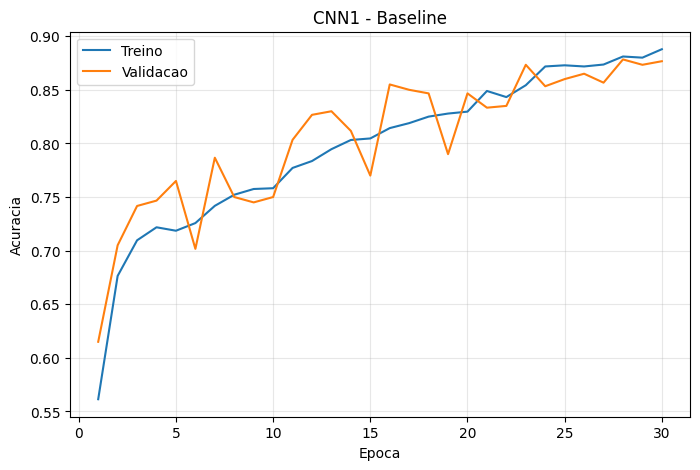

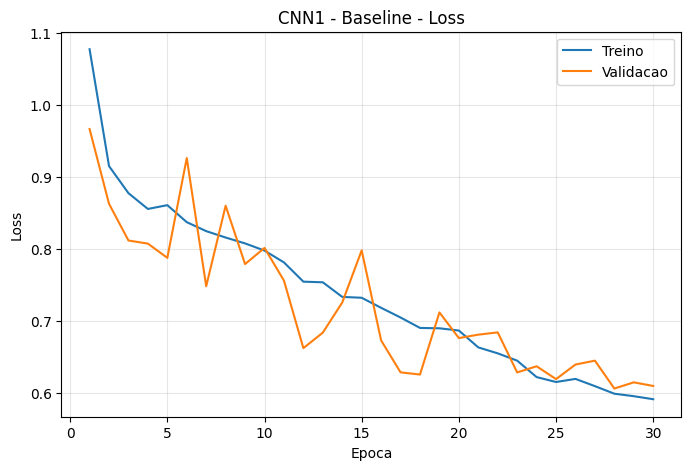

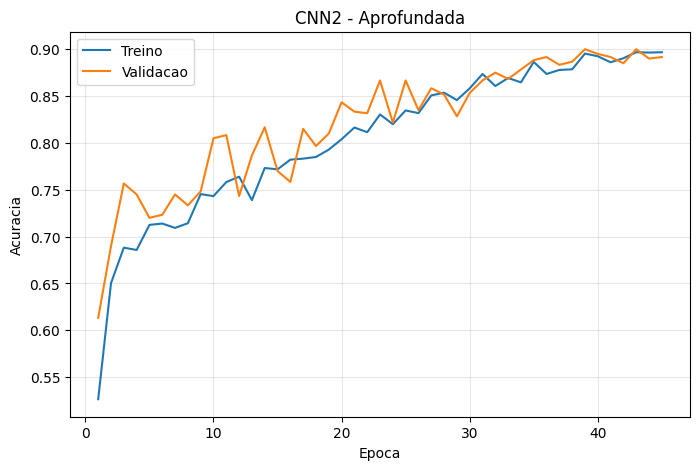

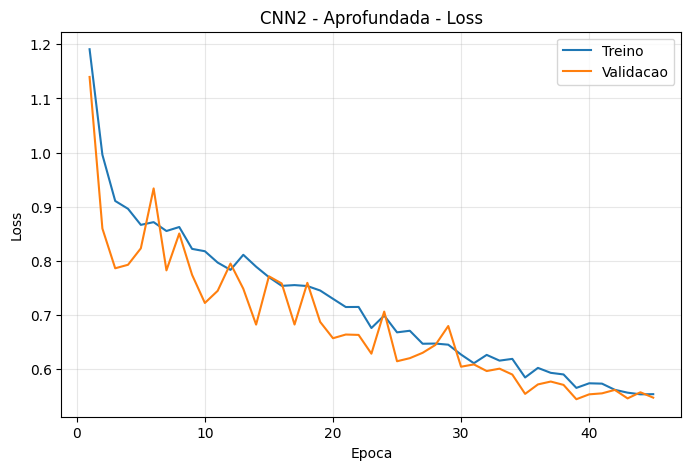

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history['epoch'], history['train_acc'], label='Treino')
    plt.plot(history['epoch'], history['val_acc'], label='Validacao')
    plt.xlabel('Epoca')
    plt.ylabel('Acuracia')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history['epoch'], history['train_loss'], label='Treino')
    plt.plot(history['epoch'], history['val_loss'], label='Validacao')
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    plt.title(title + ' - Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(hist_1, 'CNN1 - Baseline')
plot_history(hist_2, 'CNN2 - Aprofundada')


## 9. Avaliacao no conjunto de teste


In [15]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

test_loss_1, test_acc_1, test_f1_1, y_true_1, y_pred_1, y_prob_1 = evaluate(model_1, test_loader, criterion, DEVICE)
test_loss_2, test_acc_2, test_f1_2, y_true_2, y_pred_2, y_prob_2 = evaluate(model_2, test_loader, criterion, DEVICE)

comparison = pd.DataFrame([
    {'modelo': 'CNN1 - Baseline', 'test_loss': test_loss_1, 'test_accuracy': test_acc_1,
     'test_f1_macro': test_f1_1, 'parametros': count_parameters(model_1)},
    {'modelo': 'CNN2 - Aprofundada', 'test_loss': test_loss_2, 'test_accuracy': test_acc_2,
     'test_f1_macro': test_f1_2, 'parametros': count_parameters(model_2)}
])

comparison


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,modelo,test_loss,test_accuracy,test_f1_macro,parametros
0,CNN1 - Baseline,0.530495,0.920000,0.919416,2191908
1,CNN2 - Aprofundada,0.453793,0.958333,0.958152,1206628


In [16]:
print('Relatorio CNN1 - Baseline')
print(classification_report(y_true_1, y_pred_1, target_names=class_names, digits=4))

print('Relatorio CNN2 - Aprofundada')
print(classification_report(y_true_2, y_pred_2, target_names=class_names, digits=4))


Relatorio CNN1 - Baseline
                 precision    recall  f1-score   support

    corpos_agua     0.9456    0.9267    0.9360       150
vegetacao_densa     0.9097    0.8733    0.8912       150
    area_urbana     0.8982    1.0000    0.9464       150
  area_agricola     0.9296    0.8800    0.9041       150

       accuracy                         0.9200       600
      macro avg     0.9208    0.9200    0.9194       600
   weighted avg     0.9208    0.9200    0.9194       600

Relatorio CNN2 - Aprofundada
                 precision    recall  f1-score   support

    corpos_agua     0.9667    0.9667    0.9667       150
vegetacao_densa     0.9527    0.9400    0.9463       150
    area_urbana     0.9677    1.0000    0.9836       150
  area_agricola     0.9456    0.9267    0.9360       150

       accuracy                         0.9583       600
      macro avg     0.9582    0.9583    0.9582       600
   weighted avg     0.9582    0.9583    0.9582       600



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

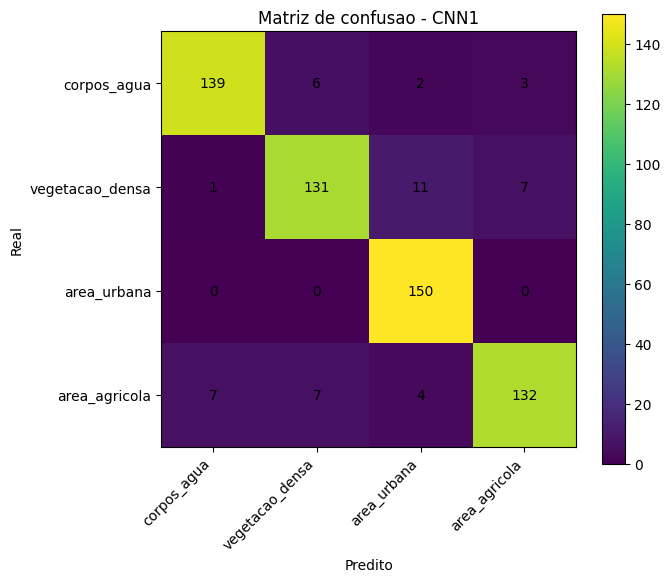

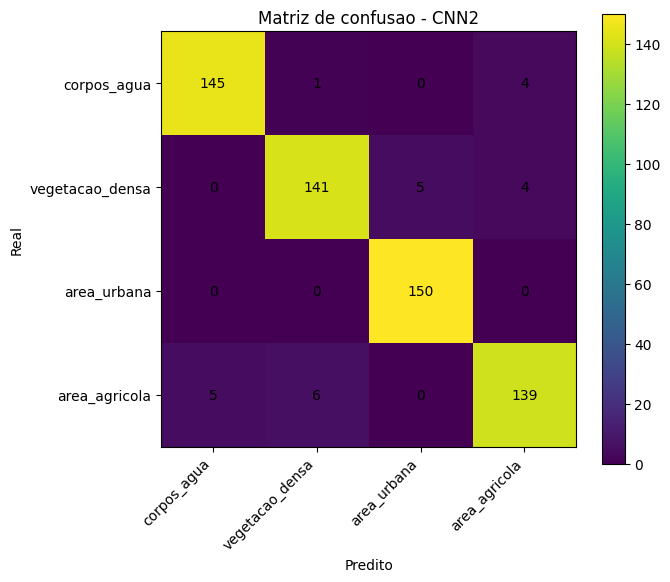

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_1, y_pred_1, 'Matriz de confusao - CNN1')
plot_confusion_matrix(y_true_2, y_pred_2, 'Matriz de confusao - CNN2')


## 10. Escolha do melhor modelo

O melhor modelo e definido pelo maior F1-macro no teste. O F1-macro e adequado porque avalia o desempenho medio entre classes, sem favorecer apenas a classe mais facil.


In [18]:
if test_f1_2 >= test_f1_1:
    best_model = model_2
    best_name = 'CNN2 - Aprofundada'
    best_path = path_2
    best_y_true, best_y_pred, best_y_prob = y_true_2, y_pred_2, y_prob_2
    best_acc, best_f1 = test_acc_2, test_f1_2
else:
    best_model = model_1
    best_name = 'CNN1 - Baseline'
    best_path = path_1
    best_y_true, best_y_pred, best_y_prob = y_true_1, y_pred_1, y_prob_1
    best_acc, best_f1 = test_acc_1, test_f1_1

print('Melhor modelo:', best_name)
print(f'Acuracia no teste: {best_acc:.4f}')
print(f'F1-macro no teste: {best_f1:.4f}')

if best_acc >= 0.88:
    print('A meta de referencia de 88% foi atingida.')
else:
    print('A meta de referencia de 88% nao foi atingida. A justificativa tecnica deve discutir tamanho do dataset, uso apenas de RGB, resolucao 64 x 64 e sobreposicao visual entre classes.')


Melhor modelo: CNN2 - Aprofundada
Acuracia no teste: 0.9583
F1-macro no teste: 0.9582
A meta de referencia de 88% foi atingida.


## 11. Exemplos de acertos e erros

Esta secao permite analisar qualitativamente o comportamento do modelo, conforme exigido na entrega.


In [19]:
def collect_test_images(model, loader, max_items=300):
    model.eval()
    records = []
    with torch.no_grad():
        for images, labels in loader:
            images_dev = images.to(DEVICE)
            outputs = model(images_dev)
            probs = torch.softmax(outputs, dim=1).cpu()
            preds = torch.argmax(probs, dim=1)
            for img, label, pred, prob in zip(images, labels, preds, probs):
                records.append({
                    'image': img,
                    'true': int(label),
                    'pred': int(pred),
                    'confidence': float(prob[pred])
                })
                if len(records) >= max_items:
                    return records
    return records

records = collect_test_images(best_model, test_loader)
correct = [r for r in records if r['true'] == r['pred']]
incorrect = [r for r in records if r['true'] != r['pred']]

print('Acertos coletados:', len(correct))
print('Erros coletados:', len(incorrect))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Acertos coletados: 287
Erros coletados: 13


In [ ]:
def plot_records(records, title, n=8):
    if len(records) == 0:
        print('Nao ha exemplos para exibir:', title)
        return
    sample = records[:n]
    plt.figure(figsize=(14, 4))
    for i, r in enumerate(sample):
        plt.subplot(1, len(sample), i + 1)
        img = denormalize_tensor(r['image']).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(
            f"Real: {idx_to_episat[r['true']]}\nPred: {idx_to_episat[r['pred']]}\nConf: {r['confidence']:.2f}",
            fontsize=8
        )
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Ordenar por maior confianca para ver os acertos mais seguros e os erros mais relevantes
correct_sorted = sorted(correct, key=lambda x: x['confidence'], reverse=True)
incorrect_sorted = sorted(incorrect, key=lambda x: x['confidence'], reverse=True)

plot_records(correct_sorted, 'Exemplos de acertos do melhor modelo', n=8)
plot_records(incorrect_sorted, 'Exemplos de erros do melhor modelo', n=8)


## 12. Interpretacao tecnica dos resultados

Use os resultados obtidos acima para preencher a conclusao tecnica. A estrutura abaixo evita afirmacoes nao comprovadas.


In [ ]:
technical_summary = f"""
Resumo tecnico:

O melhor modelo foi: {best_name}.
Acuracia no teste: {best_acc:.4f}.
F1-macro no teste: {best_f1:.4f}.

A CNN1 foi usada como arquitetura basal, com menor numero de parametros e menor capacidade de extracao hierarquica.
A CNN2 incluiu blocos convolucionais mais profundos, Batch Normalization, Dropout e Adaptive Average Pooling, permitindo maior capacidade de generalizacao.

A classificacao visual e adequada como camada ambiental complementar do EpiSat. O modelo identifica padroes de corpos hidricos, vegetacao, ocupacao urbana e areas agricolas em imagens Sentinel-2 RGB. A inferencia epidemiologica nao deve ser interpretada como deteccao direta de focos vetoriais, mas como identificacao de condicoes ambientais visualmente compativeis com maior necessidade de vigilancia.
"""
print(technical_summary)


## 13. Salvamento dos artefatos

O melhor modelo e salvo em arquivo `.pt`. Tambem sao salvos o mapeamento de classes e a tabela comparativa de metricas.


In [22]:
# Salvar melhor modelo em nome padronizado
final_model_path = ARTIFACTS_DIR / 'episat_acv_best_model.pt'
torch.save(best_model.state_dict(), final_model_path)

# Salvar metadados
metadata = {
    'class_names': class_names,
    'idx_to_episat': idx_to_episat,
    'best_model': best_name,
    'test_accuracy': float(best_acc),
    'test_f1_macro': float(best_f1),
    'image_size': IMG_SIZE,
    'normalization_mean': [0.485, 0.456, 0.406],
    'normalization_std': [0.229, 0.224, 0.225]
}

import json
with open(ARTIFACTS_DIR / 'episat_acv_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

comparison.to_csv(ARTIFACTS_DIR / 'episat_acv_model_comparison.csv', index=False)

print('Artefatos salvos em:', ARTIFACTS_DIR)
print('Modelo final:', final_model_path)


Artefatos salvos em: /content/episat_artifacts
Modelo final: /content/episat_artifacts/episat_acv_best_model.pt


## 14. Demo funcional com Gradio

A demo recebe uma imagem RGB e retorna a classe ambiental prevista, a confianca do modelo e uma interpretacao operacional para o EpiSat.

No Colab, apos executar a celula, sera gerado um link publico temporario.


In [23]:
import gradio as gr

# Reconstruir transformacao para inferencia
inference_transform = val_test_transform

risk_interpretation = {
    'corpos_agua': 'Risco ambiental alto. Presenca de corpos hidricos visiveis, relevantes para vigilancia de areas com possivel acumulacao de agua.',
    'vegetacao_densa': 'Risco ambiental moderado. Vegetacao densa pode indicar umidade, sombreamento e microambientes favoraveis a vetores em algumas regioes.',
    'area_urbana': 'Risco ambiental moderado a alto. Areas urbanas podem concentrar recipientes, drenagem inadequada e maior populacao exposta.',
    'area_agricola': 'Risco ambiental variavel. Areas agricolas podem combinar irrigacao, solo exposto, vegetacao e corpos d agua proximos.'
}

best_model.eval()

def predict_image(image):
    if image is None:
        return 'Nenhuma imagem enviada.', None

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')

    x = inference_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = best_model(x)
        probs = torch.softmax(outputs, dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_class = idx_to_episat[pred_idx]
    confidence = float(probs[pred_idx])

    prob_table = {idx_to_episat[i]: float(probs[i]) for i in range(num_classes)}

    text = (
        f'Classe prevista: {pred_class}\n'
        f'Confianca: {confidence:.2%}\n\n'
        f'Interpretacao EpiSat: {risk_interpretation[pred_class]}'
    )
    return text, prob_table

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type='pil', label='Imagem satelital RGB'),
    outputs=[
        gr.Textbox(label='Resultado'),
        gr.Label(label='Probabilidades por classe')
    ],
    title='EpiSat ACV - Classificacao de areas ambientais em imagens satelitais',
    description='CNN treinada do zero para classificar imagens Sentinel-2 RGB em classes ambientais relacionadas a vigilancia epidemiologica.'
)

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d67172357093d04374.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
